In [229]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

<h2 align="center" style="color:green">Data Loading</h2>

In [230]:
df = pd.read_excel("premiums.xlsx")
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [231]:
df.shape

(50000, 13)

In [232]:
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339


<h2 align="center" style="color:green">Exploratory Data Analysis & Data Cleaning</h2>

### Handling Missing Values

In [233]:
df.isna().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [234]:
df = df.dropna()
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [235]:
df.shape

(49976, 13)

### Checking for Duplicate Rows

In [236]:
df.duplicated().sum()

np.int64(0)

### Basic Statistical Summary

In [237]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


### Fixing `number_of_dependants`

In [238]:
df[df["number_of_dependants"]<0].shape

(72, 13)

In [239]:
df[df["number_of_dependants"]<0]["number_of_dependants"].unique()

array([-3, -1])

Since the number of dependants cannot be negative, -3 and -1 are likely data-entry errors. I will change these values to positive numbers.

In [240]:
df["number_of_dependants"] = abs(df["number_of_dependants"])
df["number_of_dependants"].describe()

count    49976.000000
mean         1.717284
std          1.491953
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

## 1. Numeric Columns

### Univariate Analysis

In [241]:
numeric_columns = df.select_dtypes(["float64", "int64"]).columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='str')

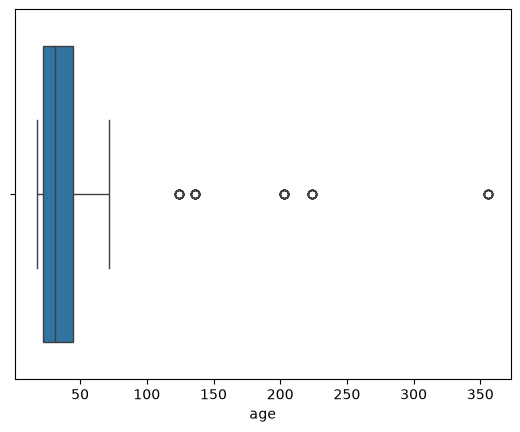

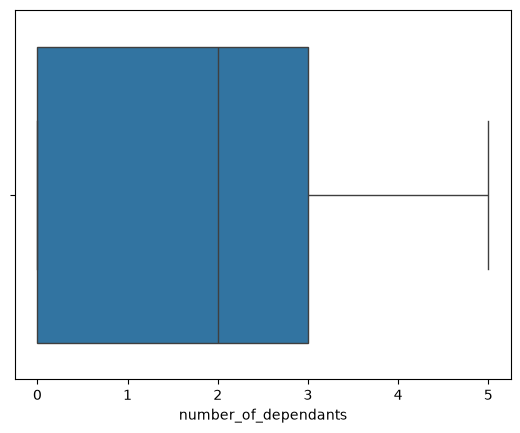

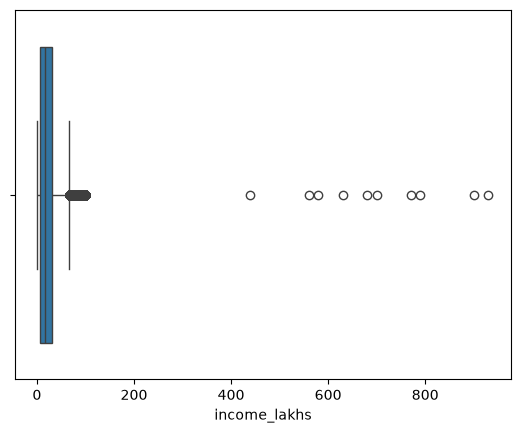

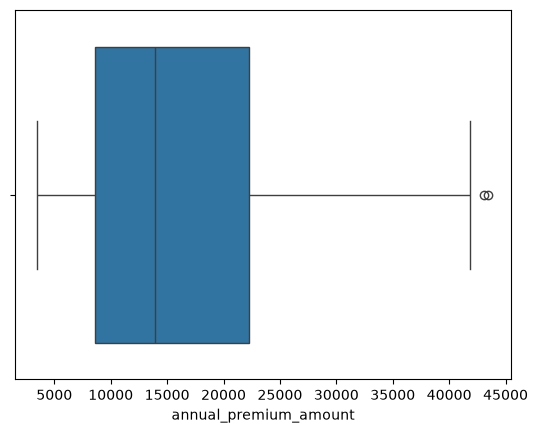

In [242]:
for col in numeric_columns:
    sns.boxplot(x = df[col])
    plt.show()
    

#### Outlier Treatment: `age`

In [243]:
df[df["age"]>100]["age"].unique()

array([224, 124, 136, 203, 356])

In [244]:
df1 = df[df["age"]<=100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,1.717617,23.025141,15766.589286
std,13.681600,1.492074,24.227912,8419.137327
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,930.000000,43471.000000


#### Outlier Treatment: `income_lakhs`

<Axes: xlabel='income_lakhs', ylabel='Count'>

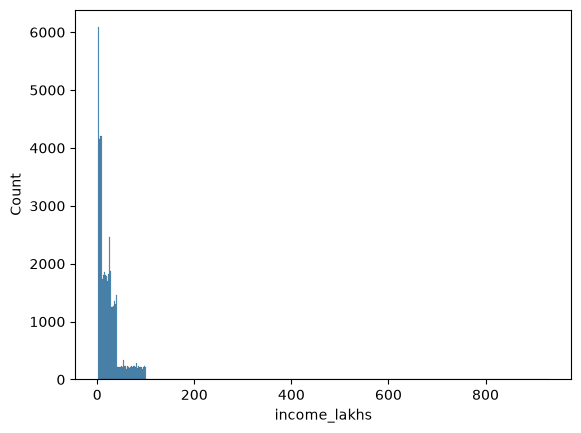

In [245]:
sns.histplot(df1["income_lakhs"])

In [246]:
def get_iqr_bounds(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [247]:
get_iqr_bounds(df1["income_lakhs"])

(-29.0, 67.0)

In [248]:
quantile_threshold = df1["income_lakhs"].quantile(0.999)
quantile_threshold

np.float64(100.0)

In [249]:
df1[df1["income_lakhs"]>quantile_threshold].shape

(10, 13)

In [250]:
df2 = df1[df1["income_lakhs"]<=quantile_threshold].copy()
df2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49908.000000,49908.000000,49908.000000,49908.000000
mean,34.401579,1.717640,22.889897,15765.739641
std,13.681604,1.492032,22.170699,8418.674061
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22270.500000
max,72.000000,5.000000,100.000000,43471.000000


#### Distribution of Numeric Features

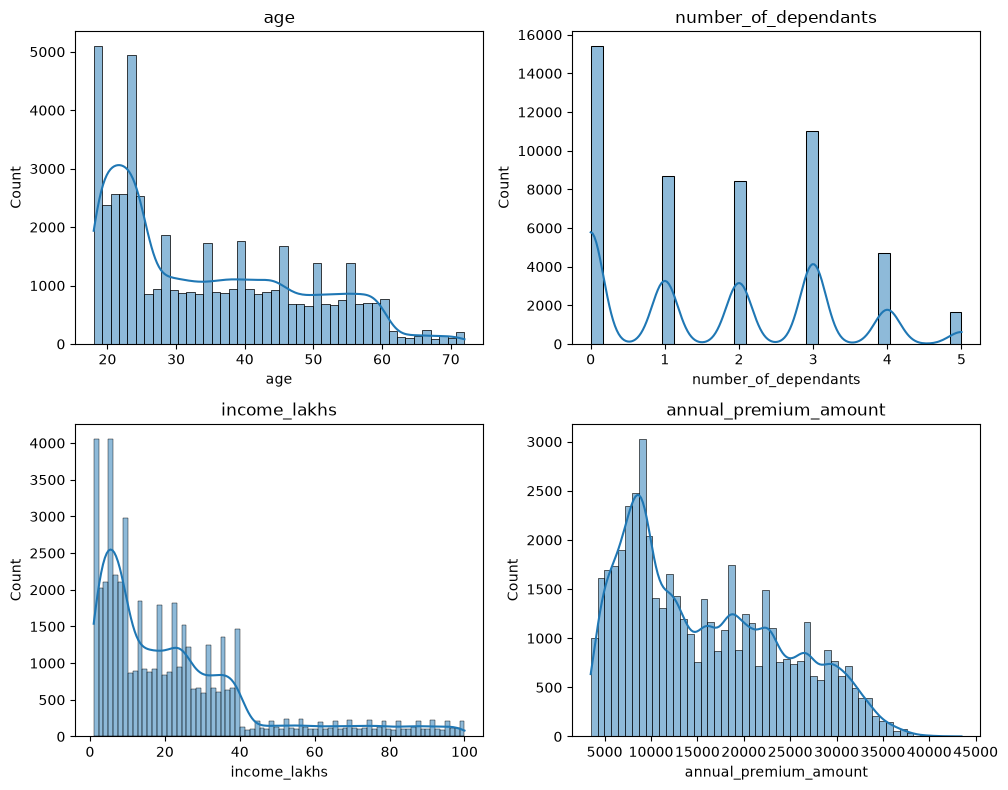

In [251]:
fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 8))

for i, column in enumerate(numeric_columns):
    ax = axs[i//2, i%2]
    sns.histplot(df2[column], kde = True, ax = ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

### Bivariate Analysis

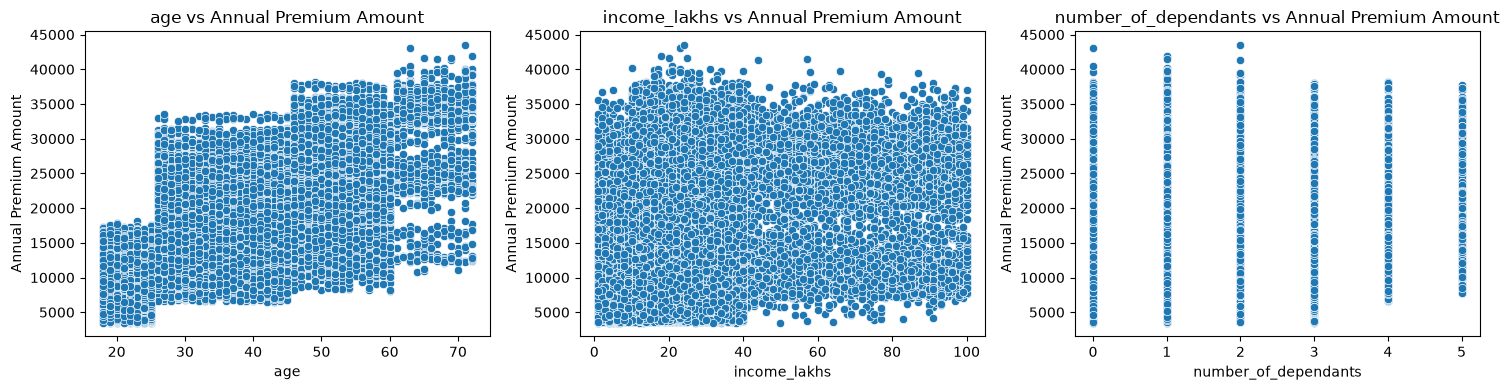

In [252]:
numeric_features = ["age", "income_lakhs", "number_of_dependants"]

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

for i, col in enumerate(numeric_features):
    ax = axs[i]
    sns.scatterplot(data=df2, x=col, y="annual_premium_amount", ax=ax)
    ax.set_title(f"{col} vs Annual Premium Amount")
    ax.set_xlabel(col)
    ax.set_ylabel("Annual Premium Amount")

plt.tight_layout()
plt.show()

## 2. Categorical Columns

In [253]:
categorical_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status', 'income_level', 'medical_history', 'insurance_plan']

In [254]:
    for col in categorical_cols:
        print(col, ":", df2[col].unique().tolist())
        print("*"*50)

gender : ['Male', 'Female']
**************************************************
region : ['Northwest', 'Southeast', 'Northeast', 'Southwest']
**************************************************
marital_status : ['Unmarried', 'Married']
**************************************************
bmi_category : ['Normal', 'Obesity', 'Overweight', 'Underweight']
**************************************************
smoking_status : ['No Smoking', 'Regular', 'Occasional', 'Smoking=0', 'Does Not Smoke', 'Not Smoking']
**************************************************
employment_status : ['Salaried', 'Self-Employed', 'Freelancer']
**************************************************
income_level : ['<10L', '10L - 25L', '> 40L', '25L - 40L']
**************************************************
medical_history : ['Diabetes', 'High blood pressure', 'No Disease', 'Diabetes & High blood pressure', 'Thyroid', 'Heart disease', 'High blood pressure & Heart disease', 'Diabetes & Thyroid', 'Diabetes & Heart disease']


#### Cleaning `smoking_status`

In [255]:
df2["smoking_status"] = df2["smoking_status"].replace({
    "Smoking=0": 'No Smoking',
    "Does Not Smoke": "No Smoking",
    "Not Smoking": "No Smoking"
})

df2["smoking_status"].unique()

<ArrowStringArray>
['No Smoking', 'Regular', 'Occasional']
Length: 3, dtype: str

### Univariate Analysis

In [256]:
pct_count = df2["gender"].value_counts(normalize = True)
pct_count

gender
Male      0.549631
Female    0.450369
Name: proportion, dtype: float64

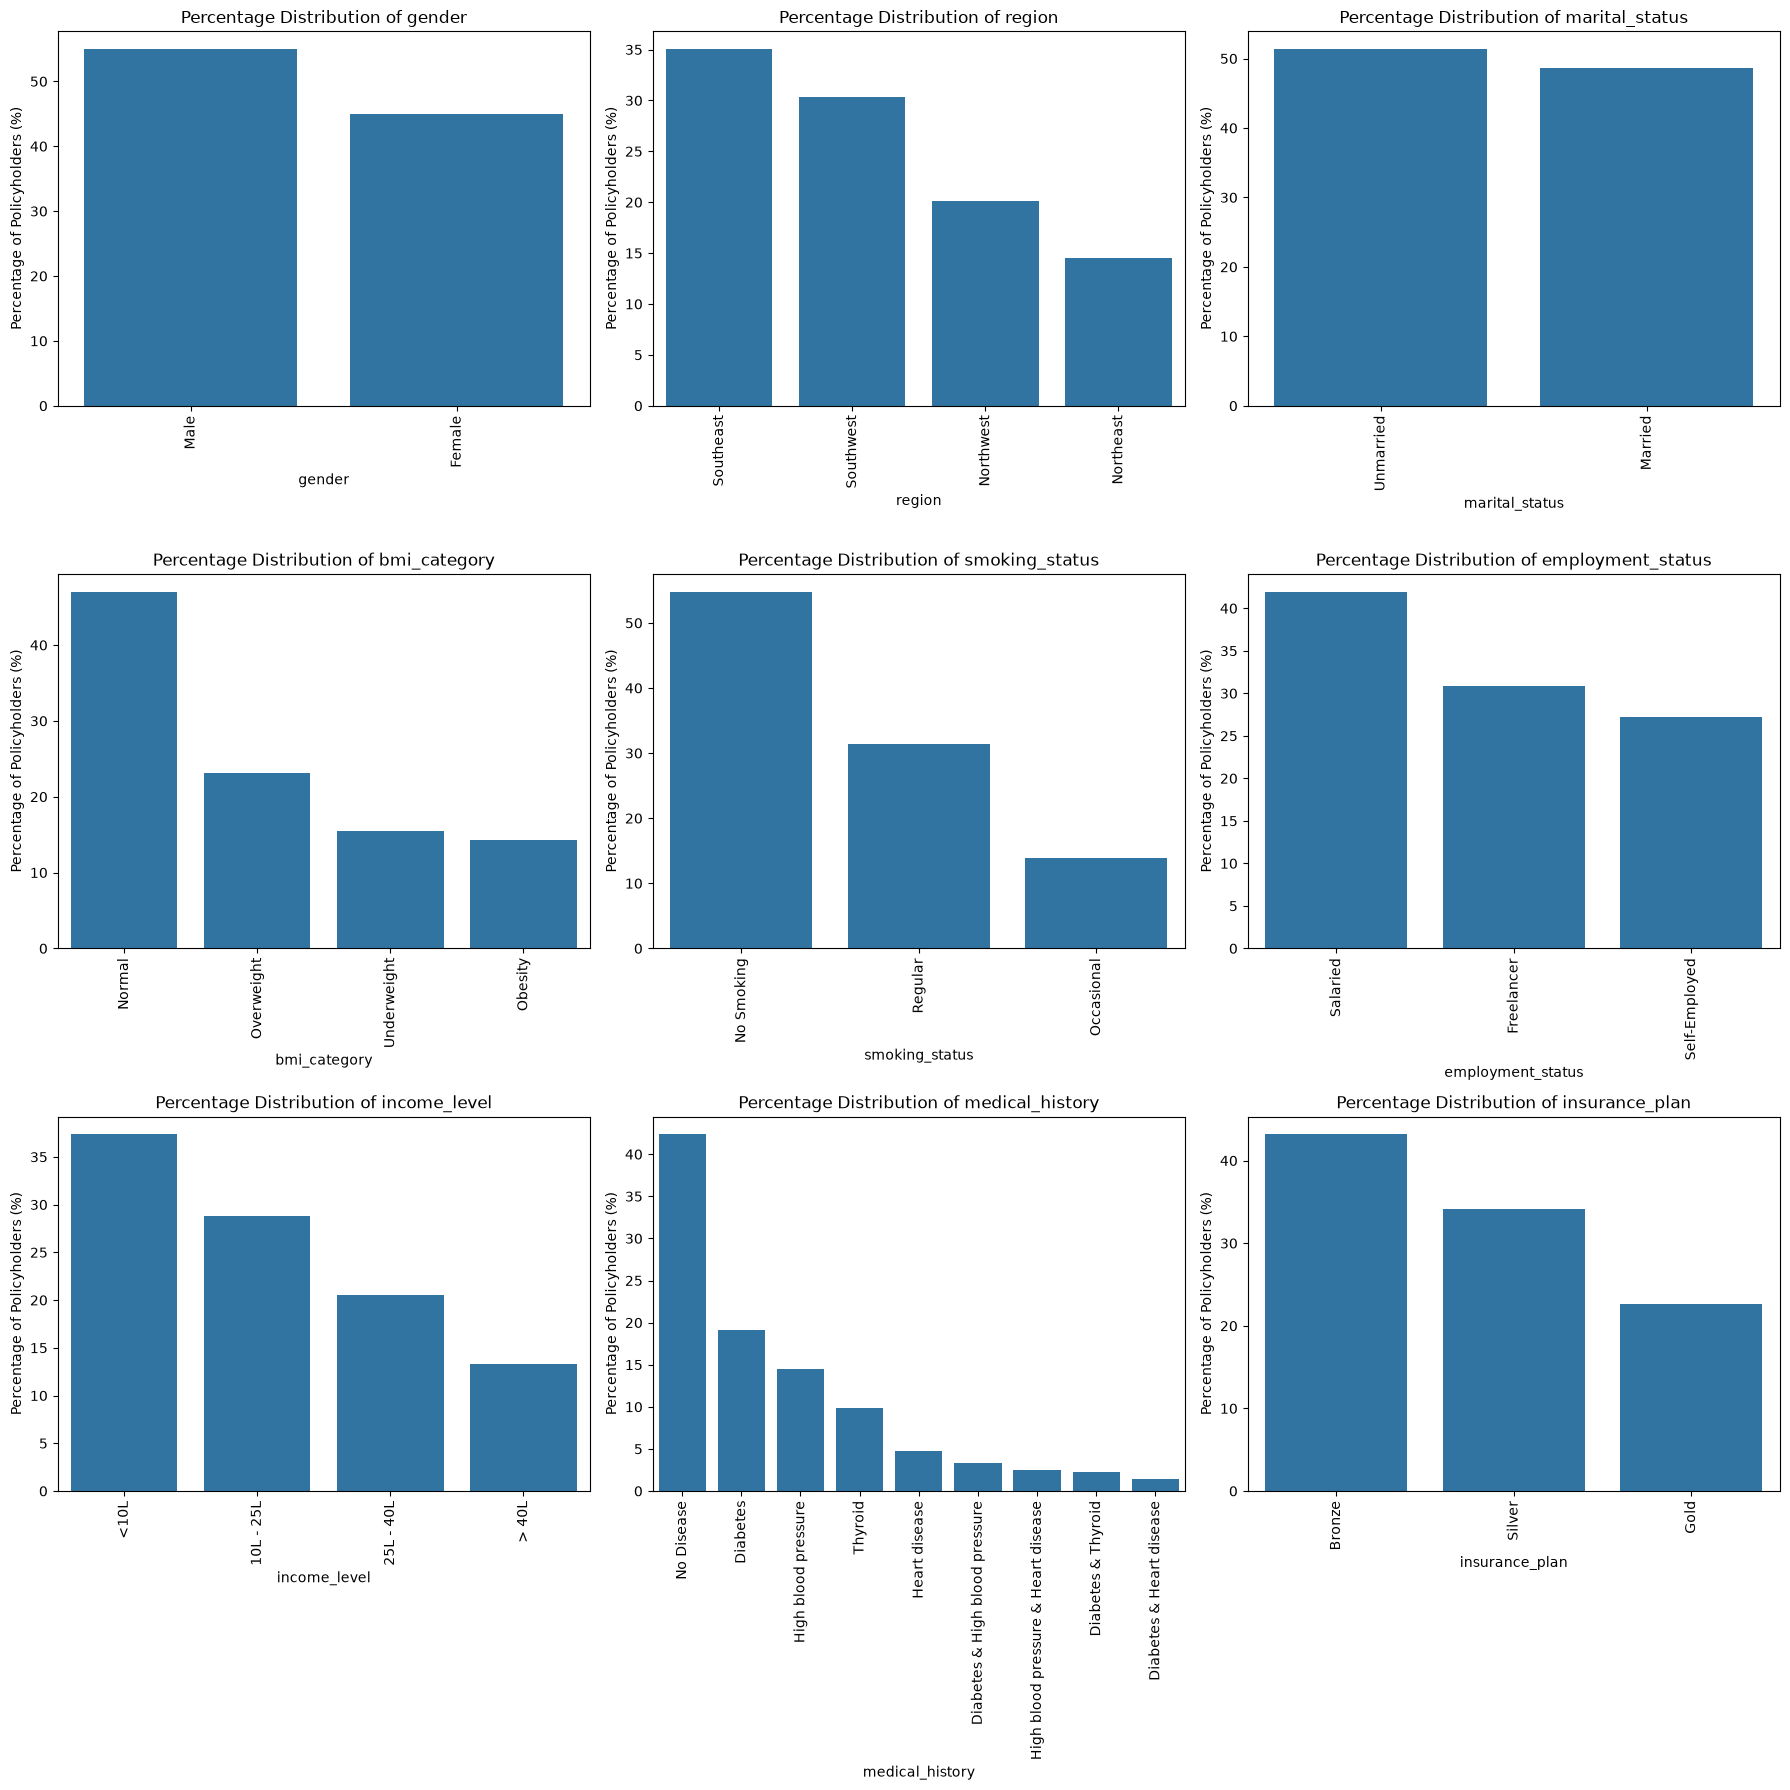

In [257]:
fig, axes = plt.subplots (3, 3, figsize=(18, 18))
axes = axes.flatten()

for ax, column in zip(axes, categorical_cols):
    category_counts = df2[column].value_counts(normalize=True) * 100

    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

### Bivariate Analysis: Income Level vs Insurance Plan

In [258]:
crosstab = pd.crosstab(df2["income_level"], df2["insurance_plan"])
crosstab

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,5307,3880,5182
25L - 40L,3683,2840,3750
<10L,12226,931,5486
> 40L,329,3653,2641


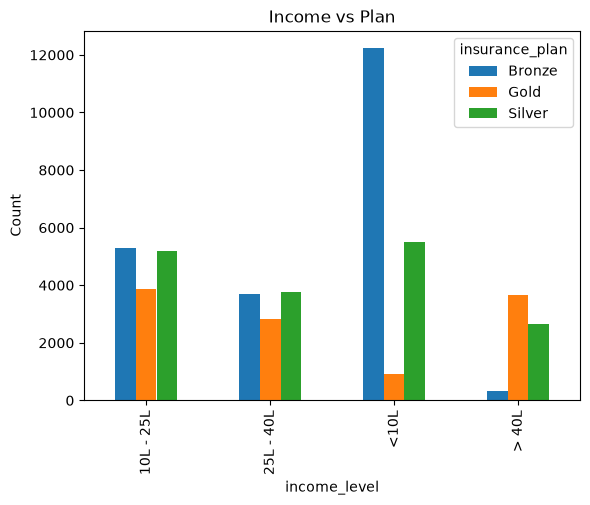

In [259]:
crosstab.plot(kind = "bar")
plt.title("Income vs Plan")
plt.ylabel("Count")
plt.show()

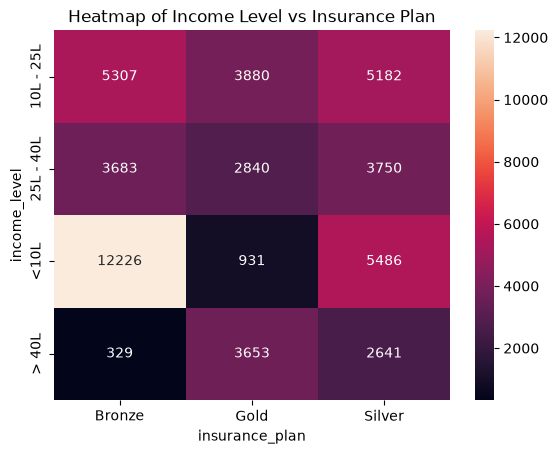

In [260]:
sns.heatmap(crosstab, annot = True, fmt = "d")
plt.title('Heatmap of Income Level vs Insurance Plan')
plt.show()

<h2 align="center" style="color:green">Feature Engineering</h2>

In [261]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339


In [262]:
df2["medical_history"].unique()

<ArrowStringArray>
[                           'Diabetes',                 'High blood pressure',
                          'No Disease',      'Diabetes & High blood pressure',
                             'Thyroid',                       'Heart disease',
 'High blood pressure & Heart disease',                  'Diabetes & Thyroid',
            'Diabetes & Heart disease']
Length: 9, dtype: str

### Calculating Risk Score

In [263]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df2[["disease1", "disease2"]] = df2["medical_history"].str.split(" & ", expand = True).apply(lambda x: x.str.lower())
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,NaN
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,NaN


In [264]:
df2["disease1"] = df2["disease1"].fillna("none")
df2["disease2"] = df2["disease2"].fillna("none")
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none


In [265]:
df2["total_risk_score"] = 0

for disease in ["disease1", "disease2"]:
    df2["total_risk_score"] += df2[disease].map(risk_scores)

max_score = df2["total_risk_score"].max()
min_score =  df2["total_risk_score"].min()
df2["normalized_risk_score"] = (df2["total_risk_score"] - min_score)/(max_score - min_score)        #Using min-max normalization formula
df2.head(3)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,none,6,0.428571


### Encoding Categorical Features

#### Encoding `insurance_plan`

In [266]:
df2["insurance_plan"].unique()

<ArrowStringArray>
['Bronze', 'Silver', 'Gold']
Length: 3, dtype: str

In [267]:
df2["insurance_plan"] = df2["insurance_plan"].map({
    'Bronze': 1, 
    'Silver': 2, 
    'Gold': 3
})
df2["insurance_plan"].unique()

array([1, 2, 3])

#### Encoding `income_level`

In [268]:
df2["income_level"].unique()

<ArrowStringArray>
['<10L', '10L - 25L', '> 40L', '25L - 40L']
Length: 4, dtype: str

In [269]:
df2["income_level"] = df2["income_level"].map({
    '<10L': 1, 
    '10L - 25L': 2,  
    '25L - 40L': 3,
    '> 40L': 4,
})

### One-Hot Encoding

In [270]:
nominal_cols = ["gender", "region", "marital_status", "bmi_category", "smoking_status", "employment_status"]
df3 = pd.get_dummies(df2, columns = nominal_cols, drop_first = True, dtype = int)
df3.head(3)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,none,6,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,none,6,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,none,6,...,0,0,0,0,0,0,0,0,0,1


### Feature Selection

In [271]:
df4 = df3.drop(["medical_history", "disease1", "disease2", "total_risk_score"], axis = 1)

### Checking for Multicollinearity

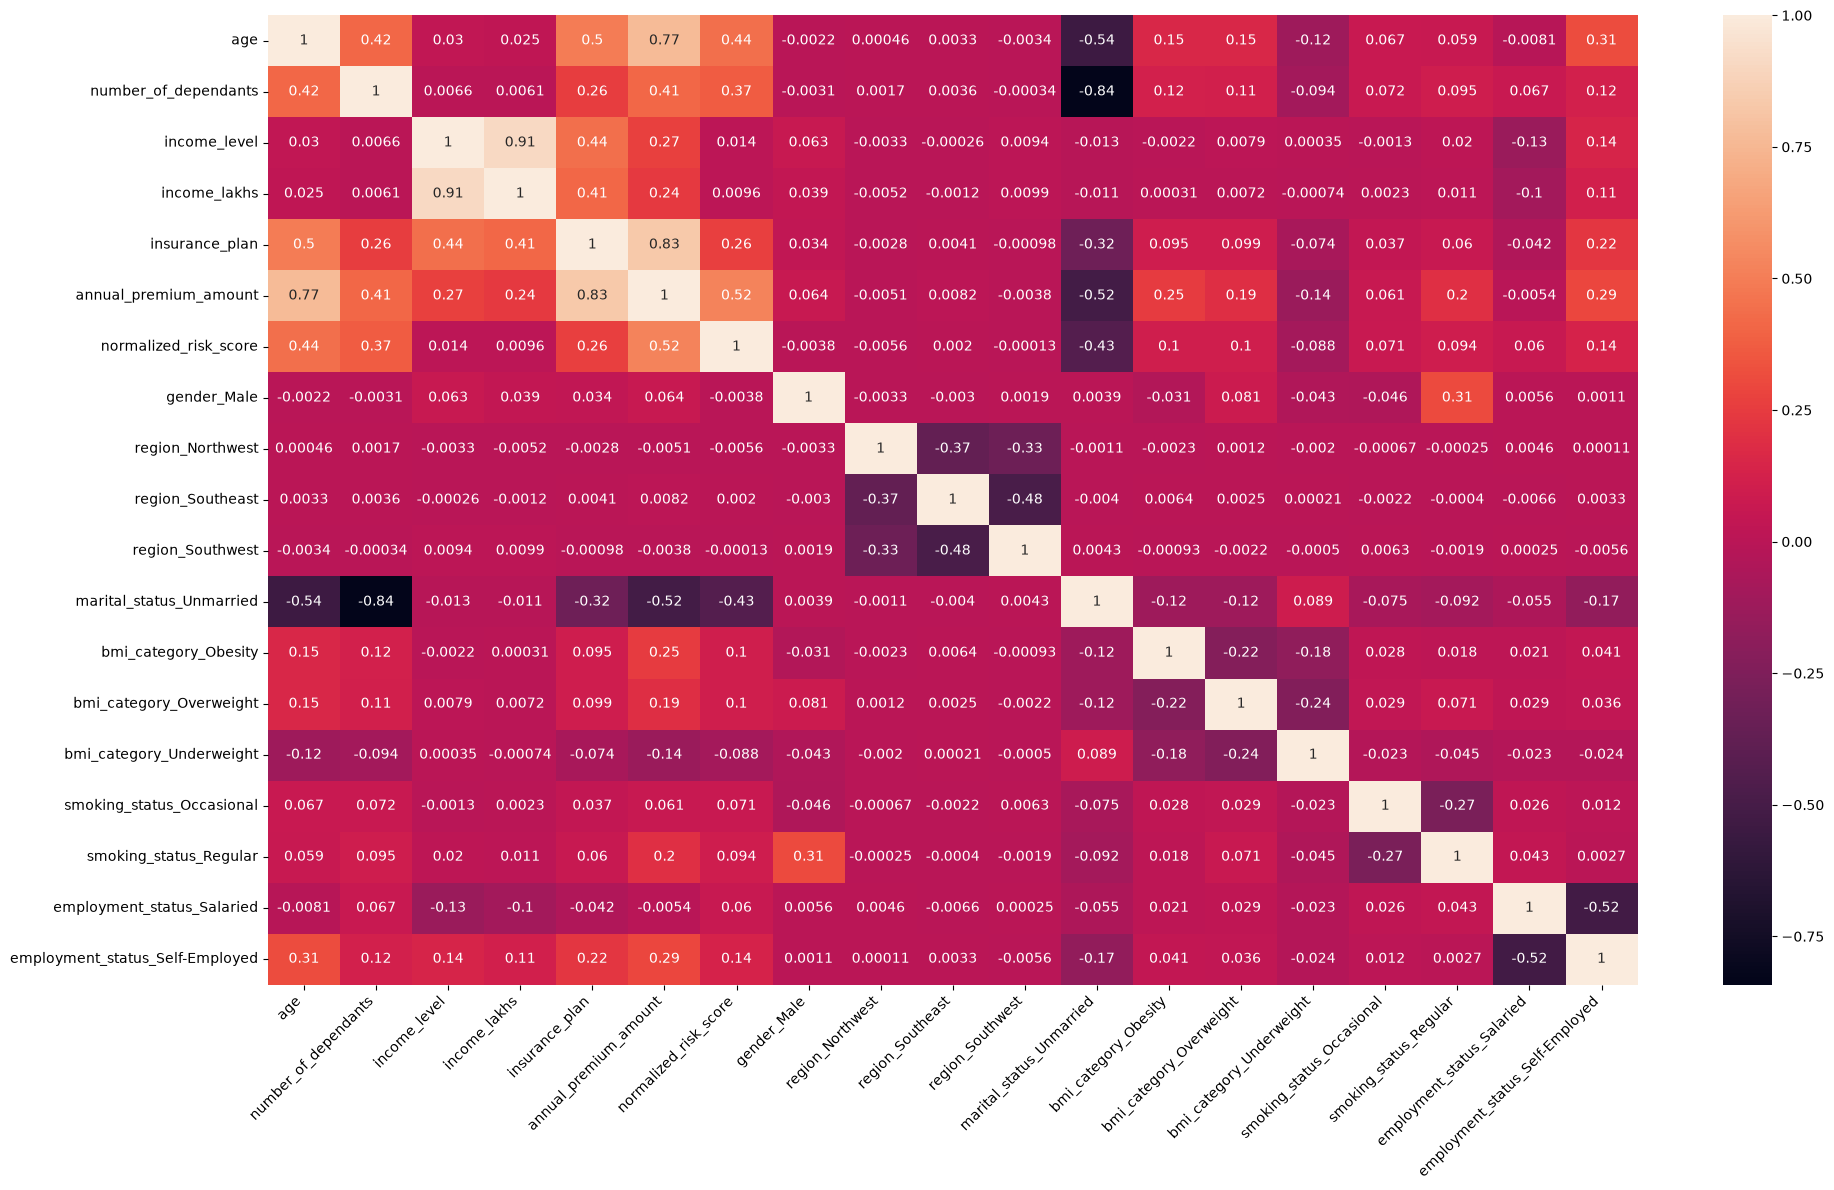

In [272]:
cm = df4.corr()

plt.figure(figsize = (20, 12))
sns.heatmap(cm, annot = True)
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()

In [273]:
X = df4.drop("annual_premium_amount", axis = 1)
y = df4["annual_premium_amount"]

from sklearn.preprocessing import MinMaxScaler
cols_to_scale = ["age", "number_of_dependants", "income_level", "income_lakhs", "insurance_plan"]
scale = MinMaxScaler()

X[cols_to_scale] = scale.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.00000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000
mean,0.303733,0.343528,0.365900,0.221110,0.397401,0.291831,0.549631,0.20093,0.350385,0.303038,0.513545,0.143183,0.231245,0.155326,0.138274,0.313857,0.419412,0.272041
std,0.253363,0.298406,0.349711,0.223946,0.392459,0.287420,0.497536,0.40070,0.477095,0.459576,0.499822,0.350263,0.421633,0.362219,0.345191,0.464064,0.493468,0.445015
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.074074,0.000000,0.000000,0.060606,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.240741,0.400000,0.333333,0.161616,0.500000,0.357143,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.600000,0.666667,0.303030,0.500000,0.428571,1.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Calculating VIF

In [274]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["Column"] = data.columns
    vif_df["VIF"] = [variance_inflation_factor(data.values, i)for i in range(data.shape[1])]
    return vif_df

In [275]:
calculate_vif(X)

,Column,VIF
0,age,4.567634
1,number_of_dependants,4.534650
2,income_level,12.450675
3,income_lakhs,11.183367
4,insurance_plan,3.584752
5,normalized_risk_score,2.687610
6,gender_Male,2.421496
7,region_Northwest,2.102556
8,region_Southeast,2.922414
9,region_Southwest,2.670666


In [276]:
calculate_vif(X.drop("income_level", axis = 1))

,Column,VIF
0,age,4.545825
1,number_of_dependants,4.526598
2,income_lakhs,2.480563
3,insurance_plan,3.445682
4,normalized_risk_score,2.687326
5,gender_Male,2.409980
6,region_Northwest,2.100789
7,region_Southeast,2.919775
8,region_Southwest,2.668314
9,marital_status_Unmarried,3.393718


In [277]:
X_reduced = X.drop("income_level", axis = 1)
X_reduced.head(2)

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.148148,0.0,0.050505,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.203704,0.4,0.050505,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0


<h2 align="center" style="color:green">Model Training</h2>

### Train-Test Split

In [278]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size = 0.3, random_state = 10)

print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (34935, 17)
x test:  (14973, 17)
y train:  (34935,)
y test:  (14973,)


### Linear Regression

In [279]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

train_score = model_lr.score(X_train, y_train)
test_score = model_lr.score(X_test, y_test)

train_score, test_score

(0.9282143576916762, 0.9280547230217837)

Checking the R2 score of training data as well to confirm model is not overfitting. If the train score was higher that means the model is overfitting. But here it's almost equal


In [280]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)

print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  5165611.913027984 RMSE:  2272.7982561212916


#### Linear Regression Coefficients

In [281]:
model_lr.intercept_

np.float64(4824.300272127099)

In [282]:
model_lr.coef_

array([11160.92646188,  -676.44399066,  -514.22981577, 12557.01293645,
        4810.35770228,   168.64666183,   -35.7192924 ,    39.96512973,
         -24.65292857,  -935.76061134,  3387.91145477,  1599.36226775,
         391.1713038 ,   735.91227798,  2234.8047119 ,   155.9846743 ,
         415.90397305])

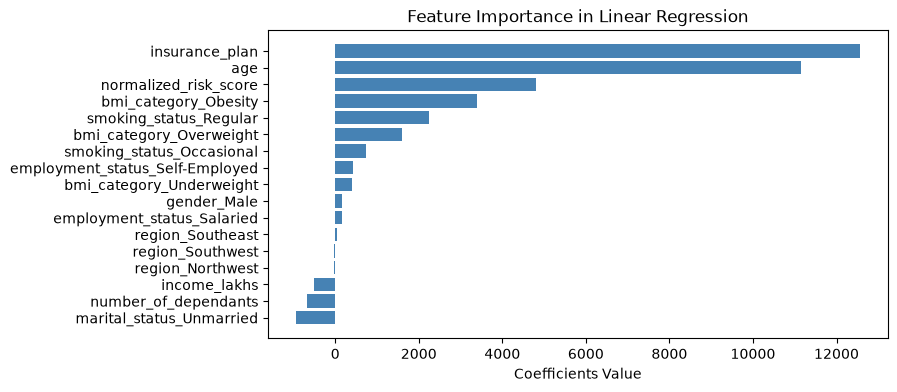

In [283]:
feature_importance = model_lr.coef_

coef_df = pd.DataFrame(feature_importance, index = X_test.columns, columns = ["Coefficients"])

coef_df = coef_df.sort_values(by = "Coefficients", ascending = True)

plt.figure(figsize = (8, 4))
plt.barh(coef_df.index, coef_df["Coefficients"], color = 'steelblue')
plt.xlabel("Coefficients Value")
plt.title("Feature Importance in Linear Regression")
plt.show()


### Ridge Regression

In [284]:
model_rg = Ridge()

model_rg.fit(X_train, y_train)
train_score = model_rg.score(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score, test_score

(0.9282143198366275, 0.9280541644640345)

In [285]:
y_pred = model_rg.predict(X_test)

mse_rg = mean_squared_error(y_test, y_pred)
rmse_rg = np.sqrt(mse_rg)

print("Ridge Regression ==> MSE: ", mse_rg, "RMSE: ", rmse_rg)

Ridge Regression ==> MSE:  5165652.017016523 RMSE:  2272.8070787060924


### XGBoost Regression

In [286]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor()
model_xgb.fit(X_train, y_train)
train_score = model_xgb.score(X_train, y_train)
test_score = model_xgb.score(X_test, y_test)
train_score, test_score

(0.9860964417457581, 0.9809534549713135)

In [287]:
y_pred = model_xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred)
rmse_xgb = np.sqrt(mse_xgb)

print("XGBoost Regression ==> MSE: ", mse_xgb, "RMSE: ", rmse_xgb)

XGBoost Regression ==> MSE:  1367525.625 RMSE:  1169.4125127601467


#### Hyperparameter Tuning

In [288]:
model_xgb = XGBRegressor()

param_grid = {
    "n_estimators": [20, 40, 50],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 4, 5]
}

random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter = 10, cv = 3, scoring= "r2", random_state = 42, n_jobs = -1)
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.9809490442276001)

In [289]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [290]:
best_model = random_search.best_estimator_
best_model

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


#### XGBoost Feature Importance

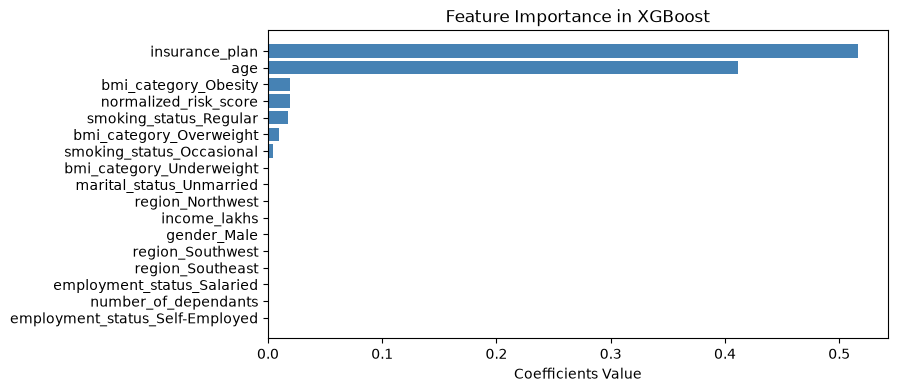

In [291]:
feature_importance = best_model.feature_importances_

coef_df = pd.DataFrame(feature_importance, index = X_test.columns, columns = ["Coefficients"])

coef_df = coef_df.sort_values(by = "Coefficients", ascending = True)

plt.figure(figsize = (8, 4))
plt.barh(coef_df.index, coef_df["Coefficients"], color = 'steelblue')
plt.xlabel("Coefficients Value")
plt.title("Feature Importance in XGBoost")
plt.show()

### Error Analysis

In [292]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = residuals*100/y_test

results_df = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
    "difference": residuals,
    "difference_pct": residuals_pct
})

results_df.head()

,actual,predicted,difference,difference_pct
3598,20554,20334.953125,-219.046875,-1.065714
35794,29647,29378.779297,-268.220703,-0.904714
43608,20560,20618.185547,58.185547,0.283004
42730,5018,7352.829590,2334.829590,46.529087
18936,8929,8203.291992,-725.708008,-8.127540


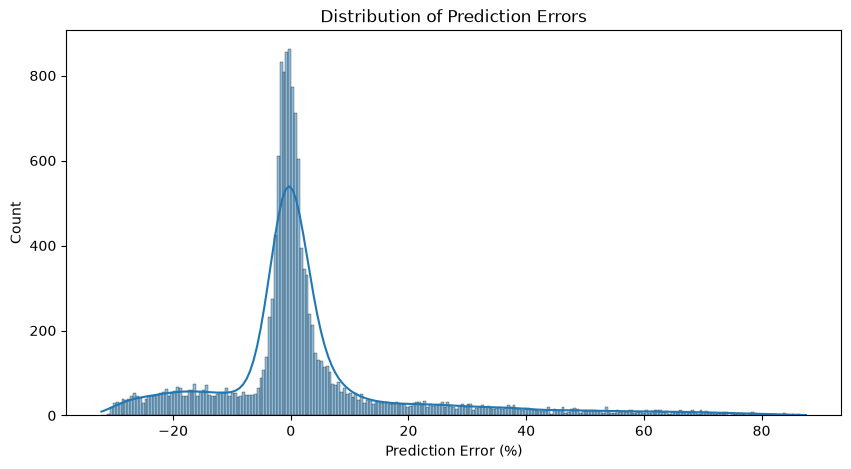

In [293]:
plt.figure(figsize=(10, 5))
sns.histplot(results_df["difference_pct"], kde=True)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error (%)")
plt.ylabel("Count")
plt.show()

In [294]:
extreme_error_threshold = 10

extreme_results_df = results_df[np.abs(results_df["difference_pct"]) > extreme_error_threshold]
extreme_results_df.shape

(4487, 4)

In [295]:
results_df.shape

(14973, 4)

In [296]:
extreme_errors_pct = extreme_results_df.shape[0]*100/results_df.shape[0]
extreme_errors_pct

29.967274427302478

In [297]:
X_test.index

Index([ 3598, 35794, 43608, 42730, 18936, 45416, 20029,  4294, 39145,  3152,
       ...
        4554,  9086,  8767,   603, 25179,  5621,  6069, 21592, 49274, 27977],
      dtype='int64', length=14973)

In [298]:
extreme_results_df.index

Index([42730, 20029,  4294, 44419,  6707, 11728, 15740, 35065,  9654, 22679,
       ...
       36158, 30386, 21184, 45020,  8249,  8767, 25179, 21592, 49274, 27977],
      dtype='int64', length=4487)

In [299]:
extreme_error_df = X_test.loc[extreme_results_df.index]
extreme_error_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
42730,0.092593,0.2,0.131313,0.0,0.428571,1,0,0,0,1,0,1,0,0,0,0,0
20029,0.018519,0.2,0.030303,0.0,0.000000,0,1,0,0,1,0,0,1,0,0,1,0
4294,0.000000,0.2,0.020202,0.0,0.000000,1,0,0,1,1,0,1,0,0,0,0,0
44419,0.055556,0.0,0.242424,0.0,0.000000,0,0,0,0,1,0,0,1,0,0,0,0
6707,0.111111,0.2,0.070707,0.5,0.000000,1,0,0,0,1,0,0,1,0,0,0,0


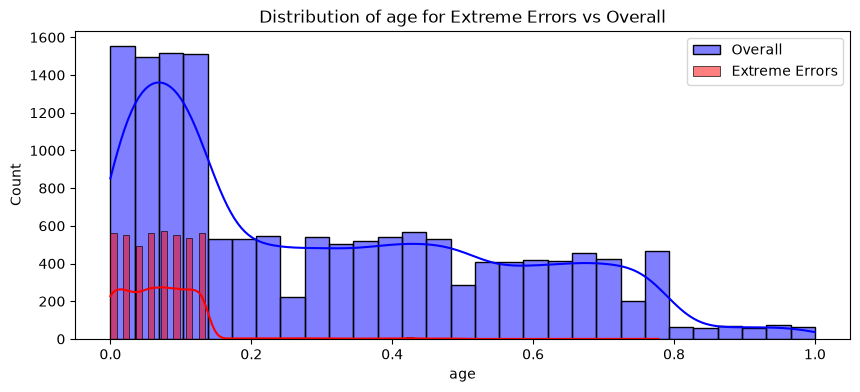

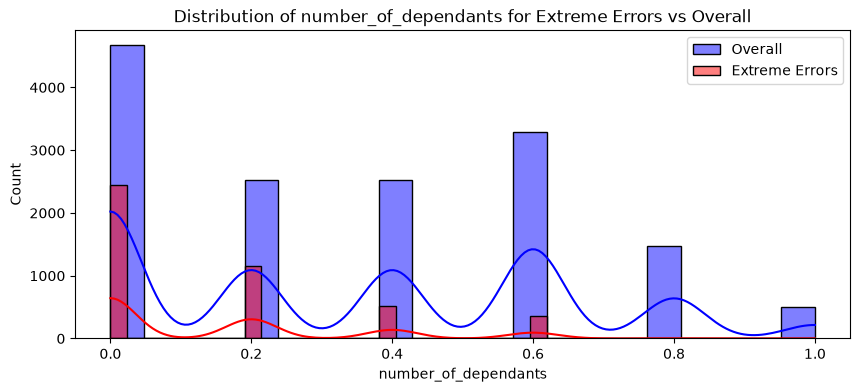

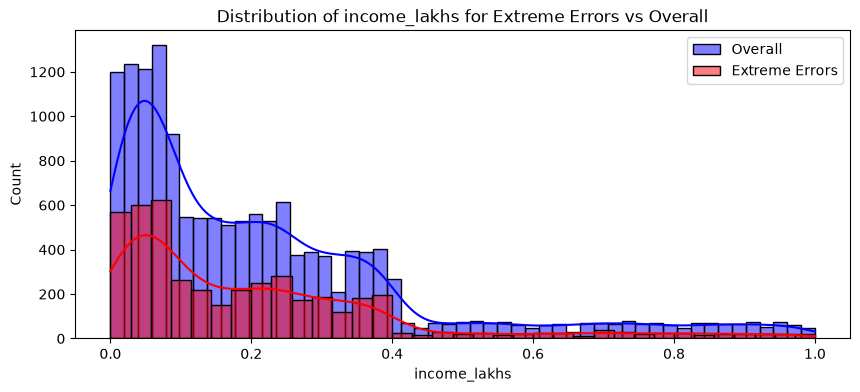

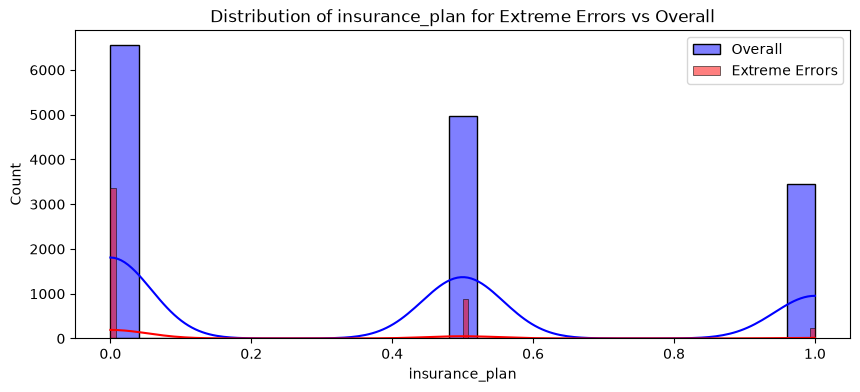

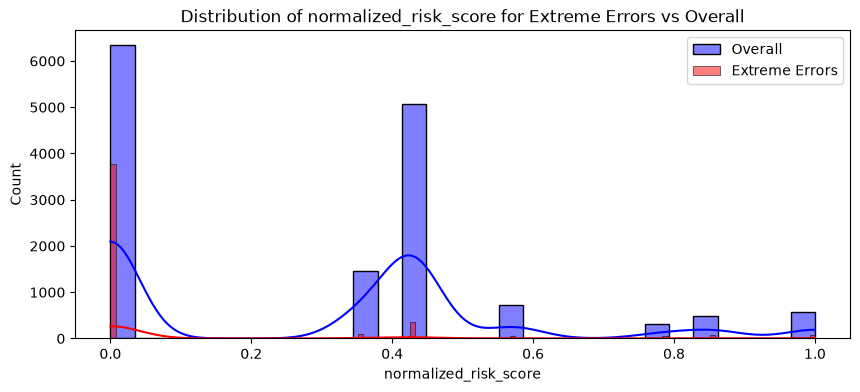

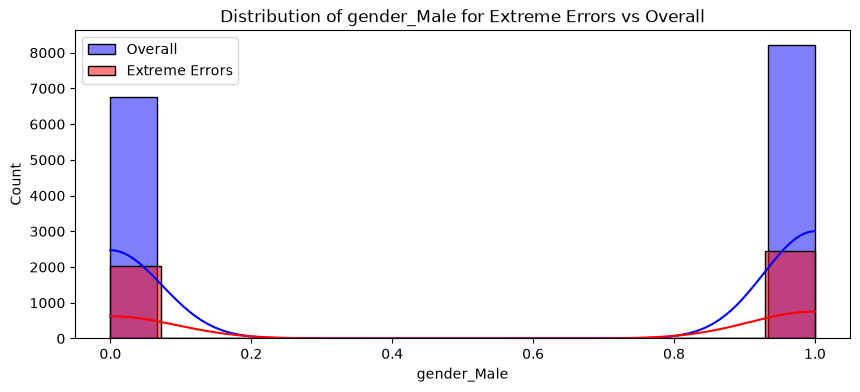

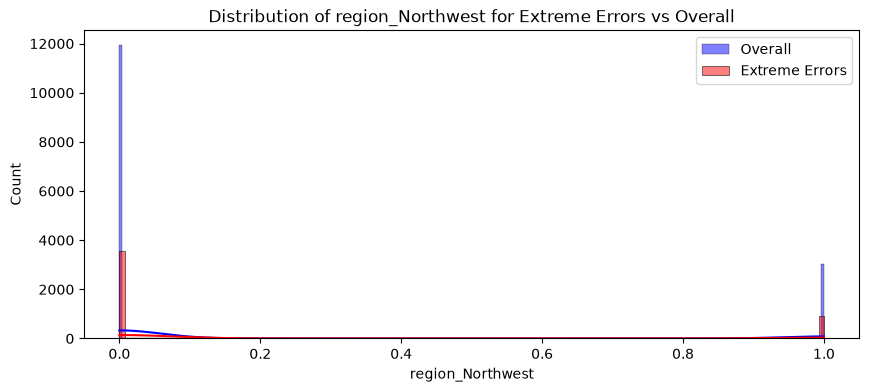

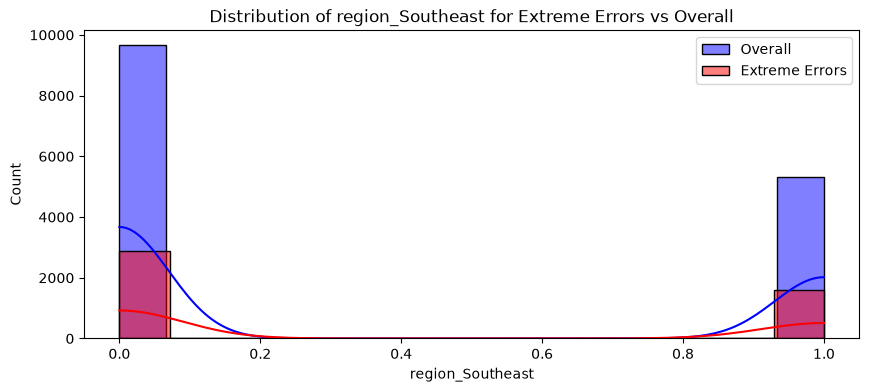

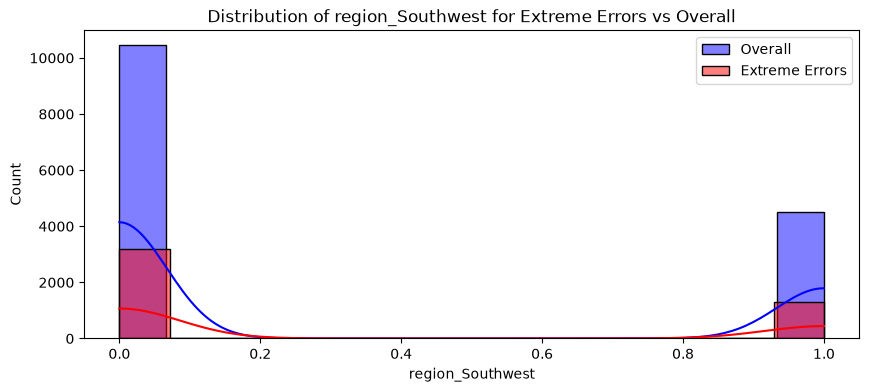

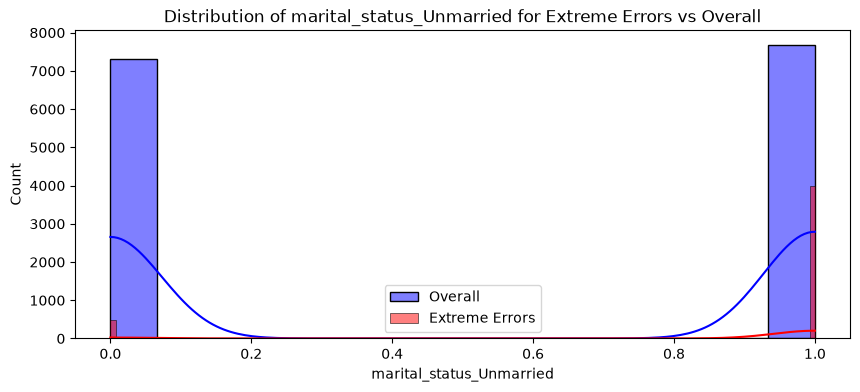

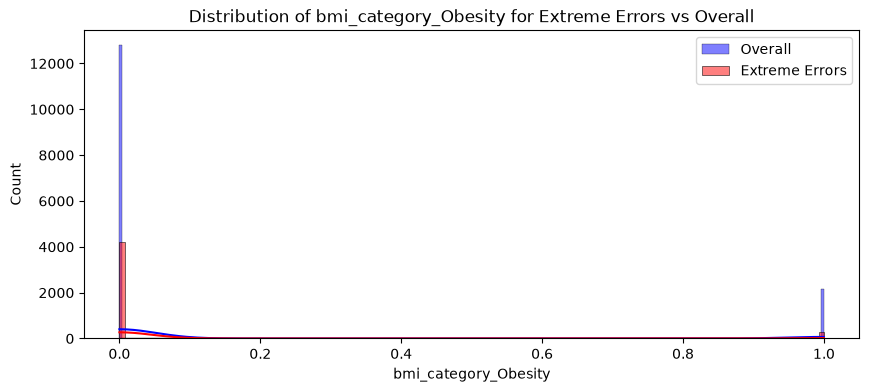

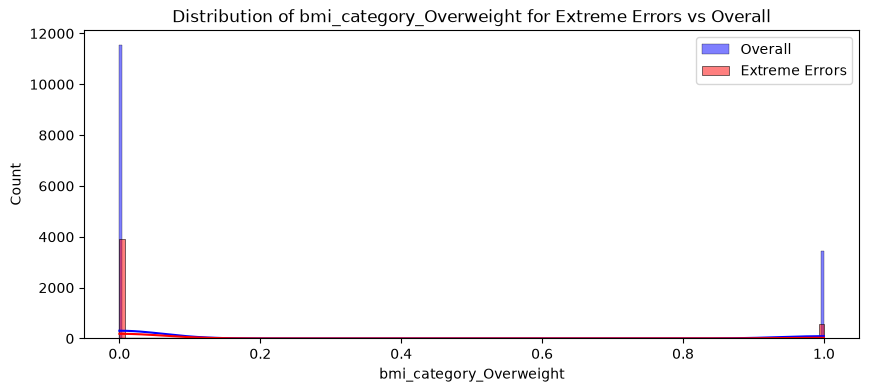

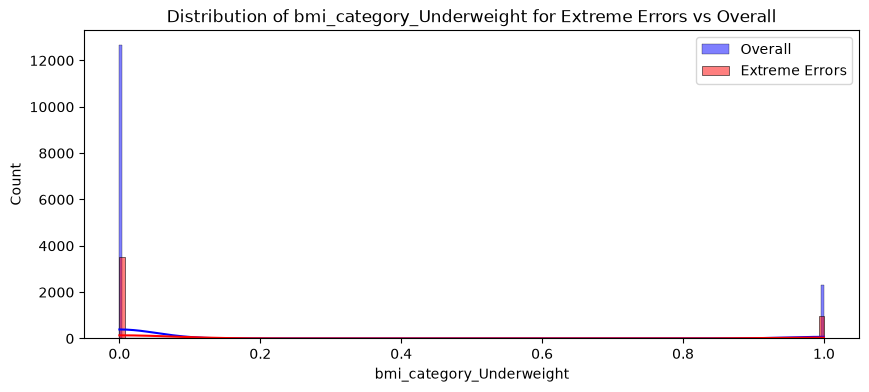

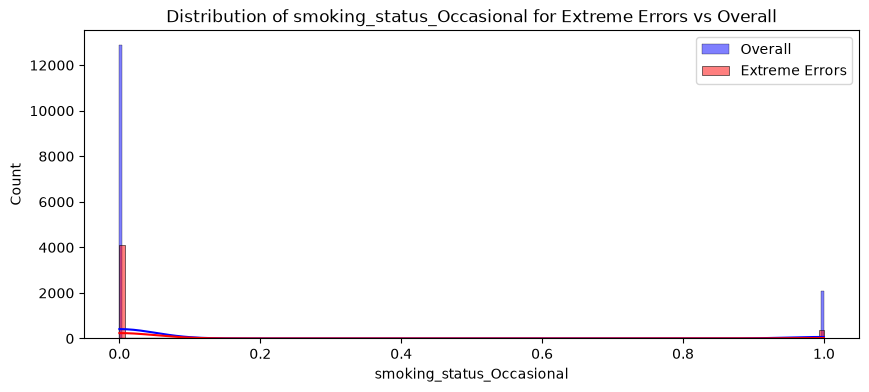

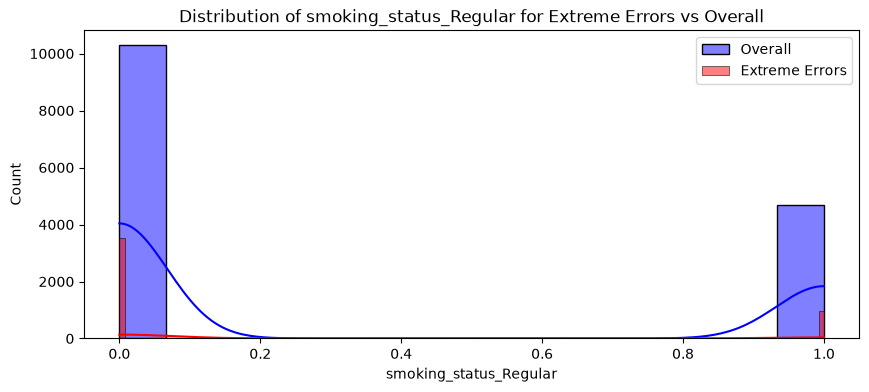

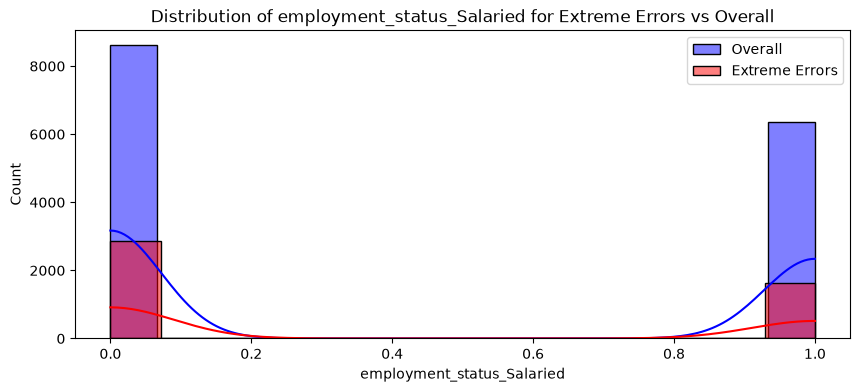

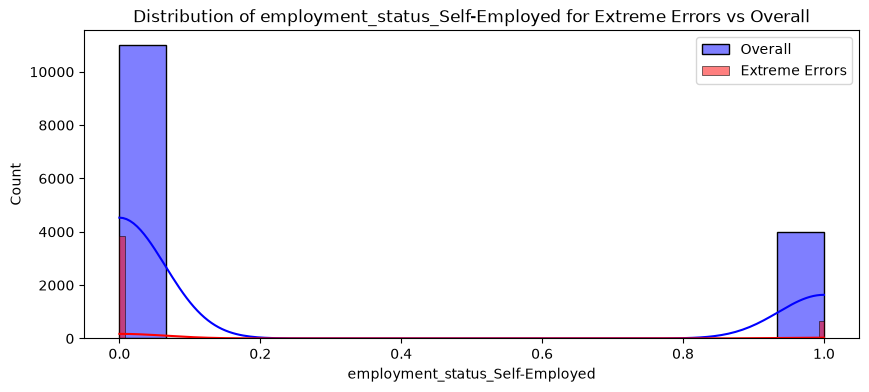

In [300]:
for feature in X_test.columns:
    plt.figure(figsize = (10,4))
    sns.histplot(X_test[feature], kde = True, label = "Overall", color = "blue", alpha = 0.5)
    sns.histplot(extreme_error_df[feature], kde = True, label = "Extreme Errors", color = "red")
    plt.legend()
    plt.title(f"Distribution of {feature} for Extreme Errors vs Overall")
    plt.show()

In [301]:
extreme_error_df["income_level"] = -1

#### Investigating Extreme Errors by Age

In [302]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scale.inverse_transform(extreme_error_df[cols_to_scale])
df_reversed

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
0,23.0,1.0,-2.0,14.0,1.0
1,19.0,1.0,-2.0,4.0,1.0
2,18.0,1.0,-2.0,3.0,1.0
3,21.0,0.0,-2.0,25.0,1.0
4,24.0,1.0,-2.0,8.0,2.0
...,...,...,...,...,...
4482,19.0,1.0,-2.0,8.0,1.0
4483,25.0,0.0,-2.0,12.0,1.0
4484,21.0,0.0,-2.0,7.0,2.0
4485,21.0,1.0,-2.0,8.0,1.0


<Axes: xlabel='age', ylabel='Count'>

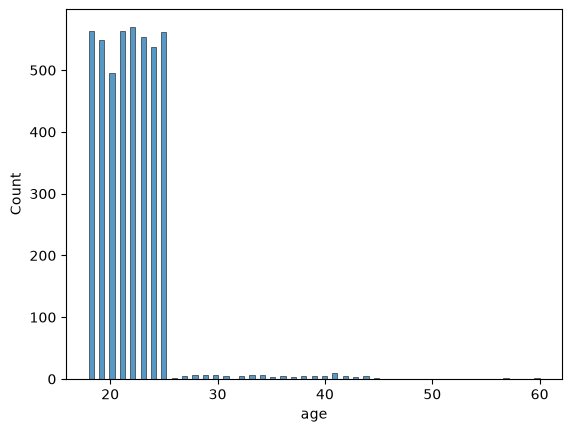

In [303]:
sns.histplot(df_reversed["age"])

In [304]:
df_reversed["age"].quantile(0.97)

np.float64(25.0)

This shows that majority of the extreme errors are coming from young age group (i.e. <25 years of age). We need to may be build a separate model for this segment